In [1]:
import pandas as pd #  pandas
import seaborn as sns # seaborn
import matplotlib.pyplot as plt # matplotlib.pyplot
from pprint import pprint # pprint para visualización metadatos
from ucimlrepo import fetch_ucirepo # se importa fetch_ucilrepo
import numpy as np # numpy
import seaborn as snst # seaborn
import statsmodels.api as sm #statsmodels
from sklearn.preprocessing import StandardScaler # scikitlearn

# Se carga el dataset DARWIN
darwin = fetch_ucirepo(id=732)
# X (features)
x = darwin.data.features

# Y (targets)
y = darwin.data.targets

# Se concatena features y target en un mismo dataframe 'df'
df = pd.concat([x,y], axis=1)

# Exploración según tarea (I)

Se crea la función analizar para dividir los dataset según el número de tarea de manera que incluye las variables correspodientes solo a dicha tarea y la variable *'class'* con los pacientes (P) y sanos (H).

Se divide el dataset, se realiza una serie de análisis descriptivos y boxplot para el conjunto de datos, según la tarea.

✅ Analizando Tarea 1 (18 variables)

Primeras filas del conjunto de datos:
   air_time1  disp_index1  gmrt_in_air1  gmrt_on_paper1  max_x_extension1  \
0       5160     0.000013    120.804174       86.853334               957   
1      51980     0.000016    115.318238       83.448681              1694   
2       2600     0.000010    229.933997      172.761858              2333   
3       2130     0.000010    369.403342      183.193104              1756   
4       2310     0.000007    257.997131      111.275889               987   

   max_y_extension1  mean_acc_in_air1  mean_acc_on_paper1  mean_gmrt1  \
0              6601          0.361800            0.217459  103.828754   
1              6998          0.272513            0.144880   99.383459   
2              5802          0.387020            0.181342  201.347928   
3              8159          0.556879            0.164502  276.298223   
4              4732          0.266077            0.145104  184.636510   

   mean_jerk_in_air1  m

/var/folders/d1/t7mn_x7d347_ghm2vrnvdsk40000gn/T/ipykernel_6966/2853655829.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', # X para la clase
/var/folders/d1/t7mn_x7d347_ghm2vrnvdsk40000gn/T/ipykernel_6966/2853655829.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', # X para la clase
/var/folders/d1/t7mn_x7d347_ghm2vrnvdsk40000gn/T/ipykernel_6966/2853655829.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', # X para la clase
/var/folders/d1/t7mn_x7d347_ghm2vrnvdsk40000gn/T/ipykernel_6966/2853655829.p

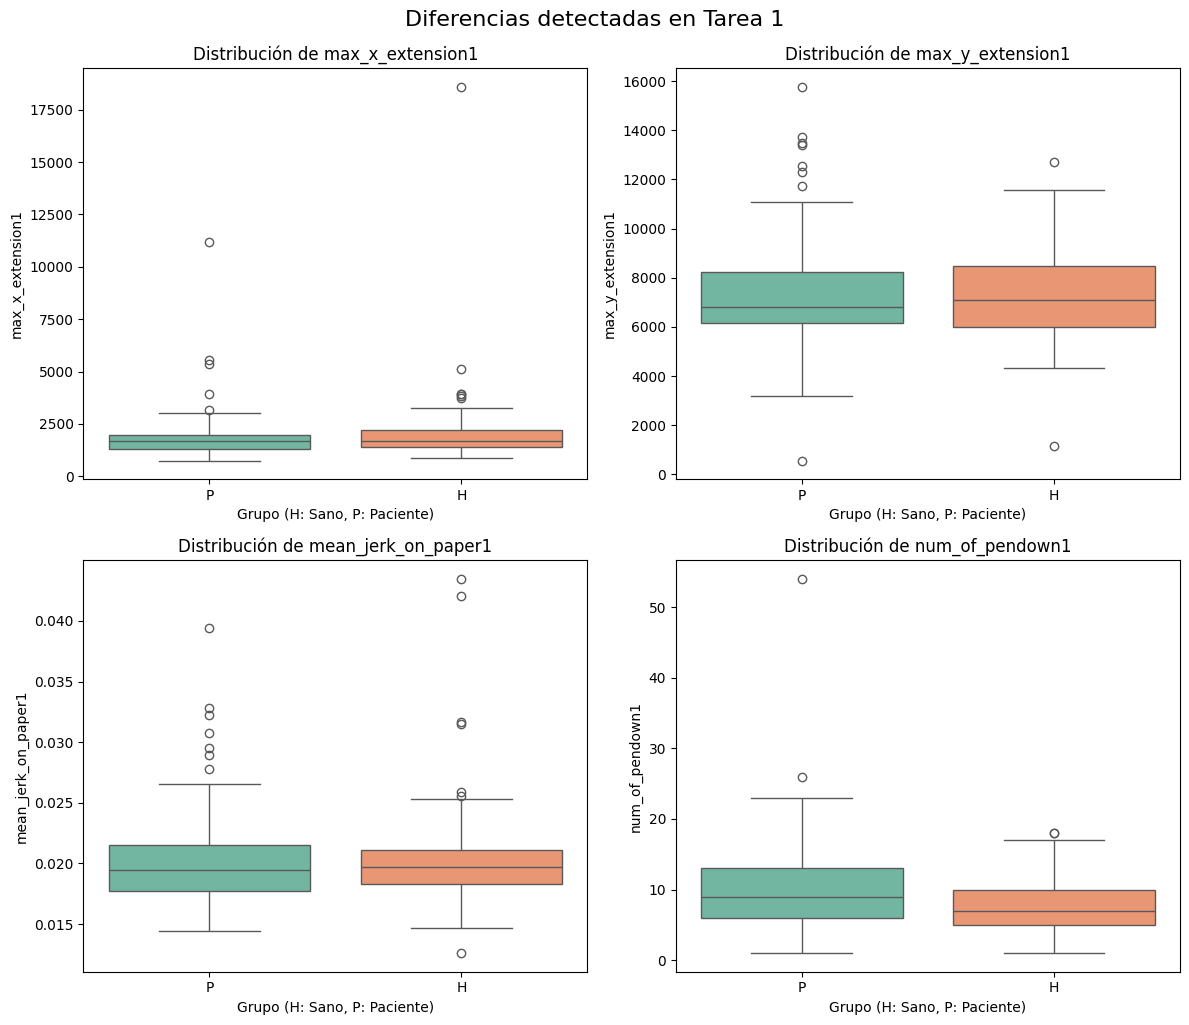

In [2]:
def analizar_tarea(df, num_tarea): # función analizar_tarea
    """
    Analiza una tarea específica (1-25)
    """
    suffix = str(num_tarea) # sufijo
    
    # --- FILTRADO ---
    # Se buscan las columnas que terminen en el número de tarea, 
    # IMPORTANTO: se asegura que el número anterior NO sea otro dígito.
    cols_tarea = [] # lista vacia
    for col in df.columns: # se recorren las columnas
        if col.endswith(suffix): # cuando la col acaba en el sufijo
            # Verificamos el prefijo del número para no confundir 1 con 11, 21...
            posible_prefijo = col[:-(len(suffix))] # prefijo
            # si el último caracter del prefijo no es un número se añade
            if not posible_prefijo[-1:].isdigit(): 
                cols_tarea.append(col)

    if not cols_tarea: # si no se encuentran columnas con el sufijo dado
        print(f"No se encontraron columnas para la tarea {num_tarea}")
        return

    print(f"✅ Analizando Tarea {num_tarea} ({len(cols_tarea)} variables)")

    # Crear un subset con las variables de la tarea + la clase
    df_tarea = df[cols_tarea + ['class']].copy()

    # -- Análisis descriptivo inicial --
    print("\nPrimeras filas del conjunto de datos:")
    print(df_tarea.head()) # primeras filas

    filas = df_tarea.shape[0] # núm filas
    columnas = df_tarea.shape[1] # núm columnas
    print("\nEstadística descriptiva inicial:")
    print(f"El conjunto de datos tiene {filas} filas y {columnas} columnas") # dimensiones

    print("\nLos nombre de las columnas son:")
    print(df_tarea.columns) # nombres cols

    print("\nEstadística descriptiva de las variables:")
    print(df_tarea.describe()) # estadística de las variables

    print("\Media de valores para pacinetes (P) vs sanos (H) en lsa variables:")
    print(df_tarea.groupby('class').mean(numeric_only=True)) # media de valores en vars para P y H
    
    """""
    # --- Heatmap de Correlaciones ---
    plt.figure(figsize=(14, 10)) # tamaño
    df_corr = df_tarea.copy() # se copia df_tarea

    # Se convierte 'class' a numeerico, P = 1 (pacientes), H = 0 (sano)
    df_corr['class'] = df_corr['class'].map({'P': 1, 'H': 0})
    
    # Se calcula la matriz de correlación
    sns.heatmap(df_corr.corr(), # matriz 
                annot=True, # valores numéricos
                cmap='coolwarm', # colores (azul -; rojo +)
                fmt=".2f", # 2 decimales
                cbar_kws={'label': 'Coef. Correlación'}) # etiqueta barra
    
    plt.title(f'Mapa de Correlación - Tarea {num_tarea}') # título
    plt.xticks(rotation=45, ha='right') # Rotación etiquetas y alineación a la dcha
    plt.show() # se muestra el gráfico 
    """

    # Boxplots de variables clave 
    # Se definen las métricas que se quieren estudiar en esta sección
    metrics = ['mean_jerk_on_paper', 'max_x_extension', 'max_y_extension', 'pressure_mean', 'num_of_pendown']
    #metrics = ['air_time', 'pressure_mean', 'mean_acc_in_air', 'total_time']

    # Se buscan los nombres reales de las columnas (pues varian ligeramente según el sufijo)
    variables_interes = [c for c in cols_tarea if any(m in c for m in metrics)]
    
    # 4 para el gráfico 2x2
    variables_interes = variables_interes[:4]
    
    # Se comprueba que la lista no este vacia
    if variables_interes:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10)) # 4 gráficos (2x2)
        axes = axes.flatten() # matriz 2x2 en lista plana
        
        # Se recorren las variables
        for i, var in enumerate(variables_interes):

            # boxplot
            sns.boxplot(x='class', # X para la clase
                        y=var, # Y para la variable
                        data=df_tarea, # df
                        ax=axes[i], # subgráfico donde se dibuja
                        palette='Set2') # colores
            
            axes[i].set_title(f'Distribución de {var}') # título según variable

            axes[i].set_xlabel('Grupo (H: Sano, P: Paciente)') # etiqueta eje X
        
        plt.tight_layout() # ajuste del espacio entre subgráficos 
        plt.suptitle(f'Diferencias detectadas en Tarea {num_tarea}', # título general
                     fontsize=16, # tamaño
                     y=1.02) # se desplaza hacia arriba
        
        plt.show() # se muestran los gráficos

    # Si no se encuentran las variables se imprime un mensaje    
    else:
        print("No se encontraron las variables específicas para los boxplots.")

# --- EJECUCIÓN ---
analizar_tarea(df, 1)

De este modo del análisis proporcionado arriba, se puede estudiar información sobre cada una de las tareas.

**Los gráficos se pueden cambiar cambiando el nombre de la variables en el código (#metrics) para el estudio de distintas variables**

# Exploración según tarea (II)

A partir del conjunto de datos asociado a la tarea determinada se realiza un análisis estadístico para el estudio de posibles outliers y regresión lógistica para el estudio de las variables mas influyentes.

Analizando Tarea 5 (18 variables)

INFORME ESTADÍSTICO: TAREA 5

Conteo de Outliers por variable:
air_time5               19
disp_index5             29
gmrt_in_air5             6
gmrt_on_paper5          11
max_x_extension5        32
max_y_extension5        37
mean_acc_in_air5        14
mean_acc_on_paper5       0
mean_gmrt5              10
mean_jerk_in_air5       22
mean_jerk_on_paper5      3
mean_speed_in_air5       5
mean_speed_on_paper5    10
num_of_pendown5         15
paper_time5             12
pressure_mean5          24
pressure_var5            7
total_time5             13
dtype: int64


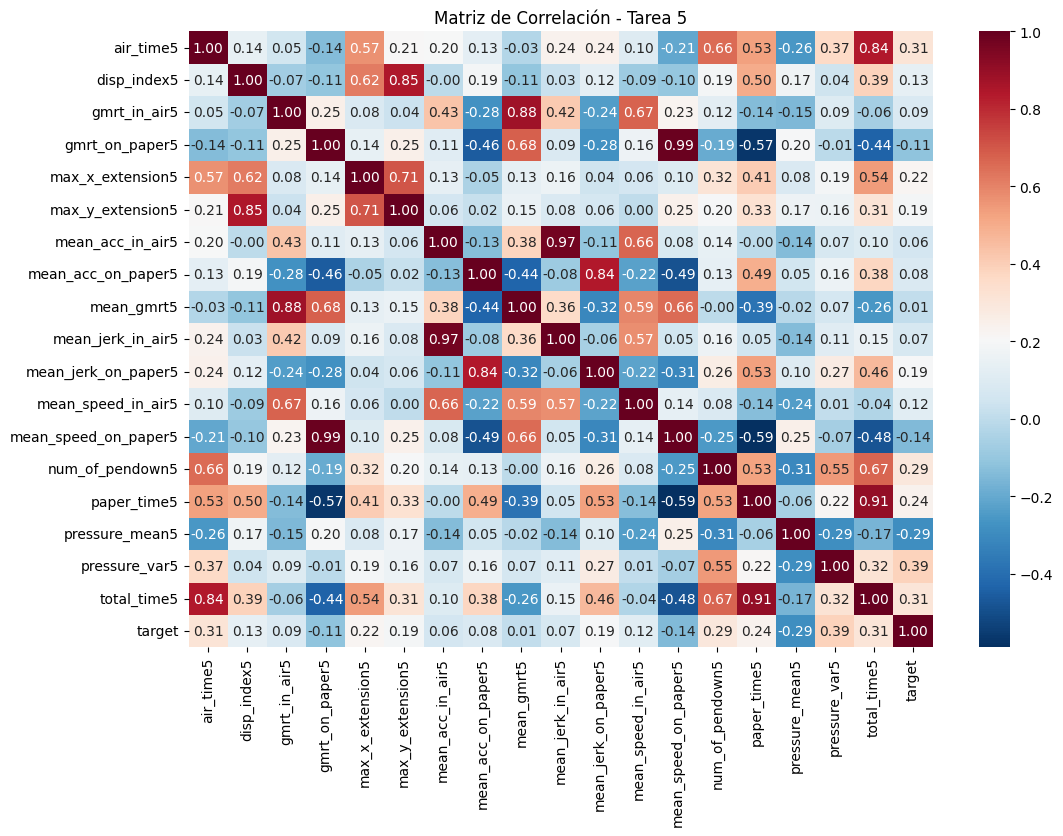

/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Variables que más influyen en el diagnóstico (Regresión):
                      Coeficiente   P-valor
mean_speed_on_paper5     5.579991  0.086259
gmrt_in_air5             3.161931       NaN
mean_jerk_on_paper5      1.556514  0.004674
max_x_extension5         1.453617  0.148979
air_time5                1.048837  1.000000
pressure_var5            0.757692  0.052246
max_y_extension5         0.695703  0.485547
mean_speed_in_air5       0.311053  0.399252
total_time5              0.182748  1.000000
mean_acc_in_air5        -0.047042  0.960848
mean_jerk_in_air5       -0.283918  0.751507
num_of_pendown5         -0.289973  0.652513
paper_time5             -0.538203  1.000000
disp_index5             -0.828261  0.371462
pressure_mean5          -0.914932  0.021213
mean_acc_on_paper5      -1.181131  0.017687
mean_gmrt5              -3.973357       NaN
gmrt_on_paper5          -4.711485       NaN


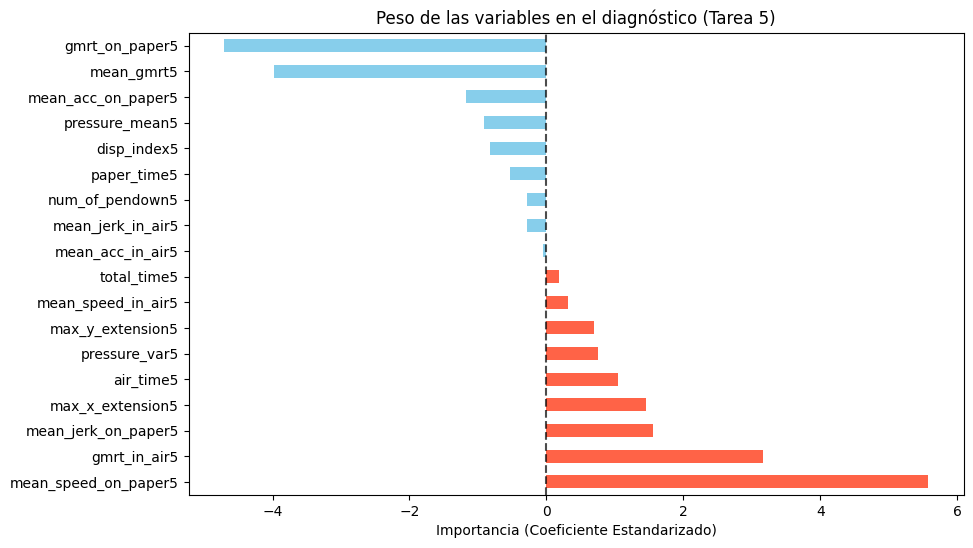

In [4]:
def analizar_tarea2(df, num_tarea): # función analizar_tarea
    """
    Analiza una tarea específica (1-25)
    """
    suffix = str(num_tarea) # sufijo
    
    # --- FILTRADO ---
    # Se buscan las columnas que terminen en el número de tarea, 
    # IMPORTANTO: se asegura que el número anterior NO sea otro dígito.
    cols_tarea = [] # lista vacia
    for col in df.columns: # se recorren las columnas
        if col.endswith(suffix): # cuando la col acaba en el sufijo
            # Verificamos el prefijo del número para no confundir 1 con 11, 21...
            posible_prefijo = col[:-(len(suffix))] # prefijo
            # si el último caracter del prefijo no es un número se añade
            if not posible_prefijo[-1:].isdigit(): 
                cols_tarea.append(col)

    if not cols_tarea: # si no se encuentran columnas con el sufijo dado
        print(f"No se encontraron columnas para la tarea {num_tarea}")
        return

    print(f"Analizando Tarea {num_tarea} ({len(cols_tarea)} variables)")

    # Crear un subset con las variables de la tarea + la clase
    df_tarea = df[cols_tarea + ['class']].copy()
    # Mapeo numérico para cálculos: P (Paciente) = 1, H (Sano) = 0
    df_tarea['target'] = df_tarea['class'].map({'P': 1, 'H': 0})
    
    print(f"\n{'='*40}") # = *40
    print(f"INFORME ESTADÍSTICO: TAREA {num_tarea}") # título
    print(f"{'='*40}")

    # DETECCIÓN DE OUTLIERS (Método IQR)
    # Outliers -> valores fuera de: [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    outliers_resumen = {} # diccionario vacio

    # Se rrecoren las columnas
    for col in cols_tarea:
        Q1 = df_tarea[col].quantile(0.25) # Q1 (25)
        Q3 = df_tarea[col].quantile(0.75) # Q3 (75)

        IQR = Q3 - Q1 # IQR

        limite_inf = Q1 - 1.5 * IQR # límite inferior
        limite_sup = Q3 + 1.5 * IQR # límite superior

        # Se determinan outliers si estan por debajo del limite inferior,
        # o por encima del limite superior
        n_outliers = df_tarea[(df_tarea[col] < limite_inf) | (df_tarea[col] > limite_sup)].shape[0]
        outliers_resumen[col] = n_outliers # se guardan en el diccionario
    
    print("\nConteo de Outliers por variable:")
    print(pd.Series(outliers_resumen)) # se presentan los outliers

    # MAPA DE CORRELACIÓN
    plt.figure(figsize=(12, 8)) # dimensiones
    sns.heatmap(df_tarea.drop('class', axis=1).corr(), annot=True, cmap='RdBu_r', fmt=".2f") # heatmap
    plt.title(f'Matriz de Correlación - Tarea {num_tarea}') # título
    plt.show() # se muestra el heatmap

    """""
    # CORR PEARSON
    # Se eliminan las variables respuestas para etudiar la correlación
    df_tarea2 = df_tarea.drop(columns=["class", "target"])
    corr_p = df_tarea2.corr(method='pearson')
    print("\nCorrelación Pearson:")
    print(corr_p)
    """
    
    # REGRESIÓN LOGÍSTICA
    X = df_tarea[cols_tarea] # se seleccionan las cols con las variables
    y = df_tarea['target'] # se selecciona la variable clase (objetivo)
    
    scaler = StandardScaler() # objeto StandardScaler para la estandarización
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns) # se estandariza X (manteniendo nombres)
    X_scaled = sm.add_constant(X_scaled) # intercepto

    try:
        modelo = sm.Logit(y, X_scaled).fit(disp=0) # se ajusta la regresión
        
        # Se crea un df con los coeficientes (sin intercepto)
        influencia = pd.DataFrame({
            'Coeficiente': modelo.params.drop('const'), # coeficiente
            'P-valor': modelo.pvalues.drop('const') # p-valor
        }).sort_values(by='Coeficiente', ascending=False) # se ordena por influencia

        print("\nVariables que más influyen en el diagnóstico (Regresión):")
        print(influencia) # se imprime el resultado

        # Gráfico de Influencia
        plt.figure(figsize=(10, 6)) # tamaño

        # Rojo para coeficientes +, azul -
        colores = ['tomato' if c > 0 else 'skyblue' for c in influencia['Coeficiente']]

        # Gráfico de barras horizontales con los coeficientes
        influencia['Coeficiente'].plot(kind='barh', color=colores)
        plt.axvline(0, color='black', linestyle='--', alpha=0.7) # línea vertical en 0
        plt.title(f'Peso de las variables en el diagnóstico (Tarea {num_tarea})')
        plt.xlabel('Importancia (Coeficiente Estandarizado)') # etiqueta eje X
        plt.show() # se muestra el gráfico
        
    except Exception as e: # se impirme el mensaje cuando la regresión falla
        print(f"\nNo se pudo completar la regresión: {e}")
        print("Estudiar si las variables están demasiado correlacionadas (multicolinealidad).")

# Uso:
analizar_tarea2(df, 5)

## Detección de outliers:

Para la detección de outliers se usa el método del rango intercuartílico (IQR), según la fórmula:

$x < Q_{1} - 1.5 \ast IQR$ ó $x > Q_{3} + 1.5 \ast IQR$

## Heatmap

Para el estudio de la correlación entre variables.

## Regresión logística

Como en las variables de la base datos se encuentran los valores con distinta escala se emplea `StandardScaler` para la estandarización de las variables.

p-valor < 0.05 muestra que dicha variable es significativa.

## Gráfico del peso de las variables

* A mayor coeficiente positivo (color rojo) mayor porbabilidad de ser paciente (P)
* A mayor coeficiente negativo (color azul) mayor porbabilidad de ser sano (H)

## Correlación de variables con Pearson

